# Notebook 4 — Data Drift Analysis
## Kaggle Bike Sharing Demand

**Objective:** Detect and quantify distributional shift between a reference dataset (first year of data — 2011) and a current dataset (second year — 2012) using statistical tests and visualisations. This simulates the continuous monitoring (CM) stage of the MLOps pipeline.

**Methods used**
- Kolmogorov-Smirnov (KS) test for numerical features
- Chi-squared test for categorical features
- Population Stability Index (PSI)
- Visual distribution comparison

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.features import get_feature_columns, add_time_features

FEATURE_COLS = get_feature_columns()
print("scipy version:", __import__("scipy").__version__)
print("Feature columns:", FEATURE_COLS)

scipy version: 1.17.1
Feature columns: ['season', 'holiday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


## 1. Load Reference and Current Data

Split the dataset chronologically:
- **Reference** — Year 2011 (training distribution)
- **Current** — Year 2012 (simulated production data)

In [2]:
PROCESSED_PATH = PROCESSED_DIR / "train_processed.csv"
df = pd.read_csv(PROCESSED_PATH, parse_dates=["datetime"])

# Split by year: 2011 = reference, 2012 = current
ref_df  = df[df["datetime"].dt.year == 2011].copy().reset_index(drop=True)
curr_df = df[df["datetime"].dt.year == 2012].copy().reset_index(drop=True)

print(f"Reference (2011): {ref_df.shape[0]:,} rows")
print(f"Current   (2012): {curr_df.shape[0]:,} rows")
print(f"\nFeature columns: {FEATURE_COLS}")

Reference (2011): 5,422 rows
Current   (2012): 5,464 rows

Feature columns: ['season', 'holiday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


## 2. Feature Distribution Comparison

Side-by-side histograms comparing the reference (2011) and current (2012) distributions for every feature.

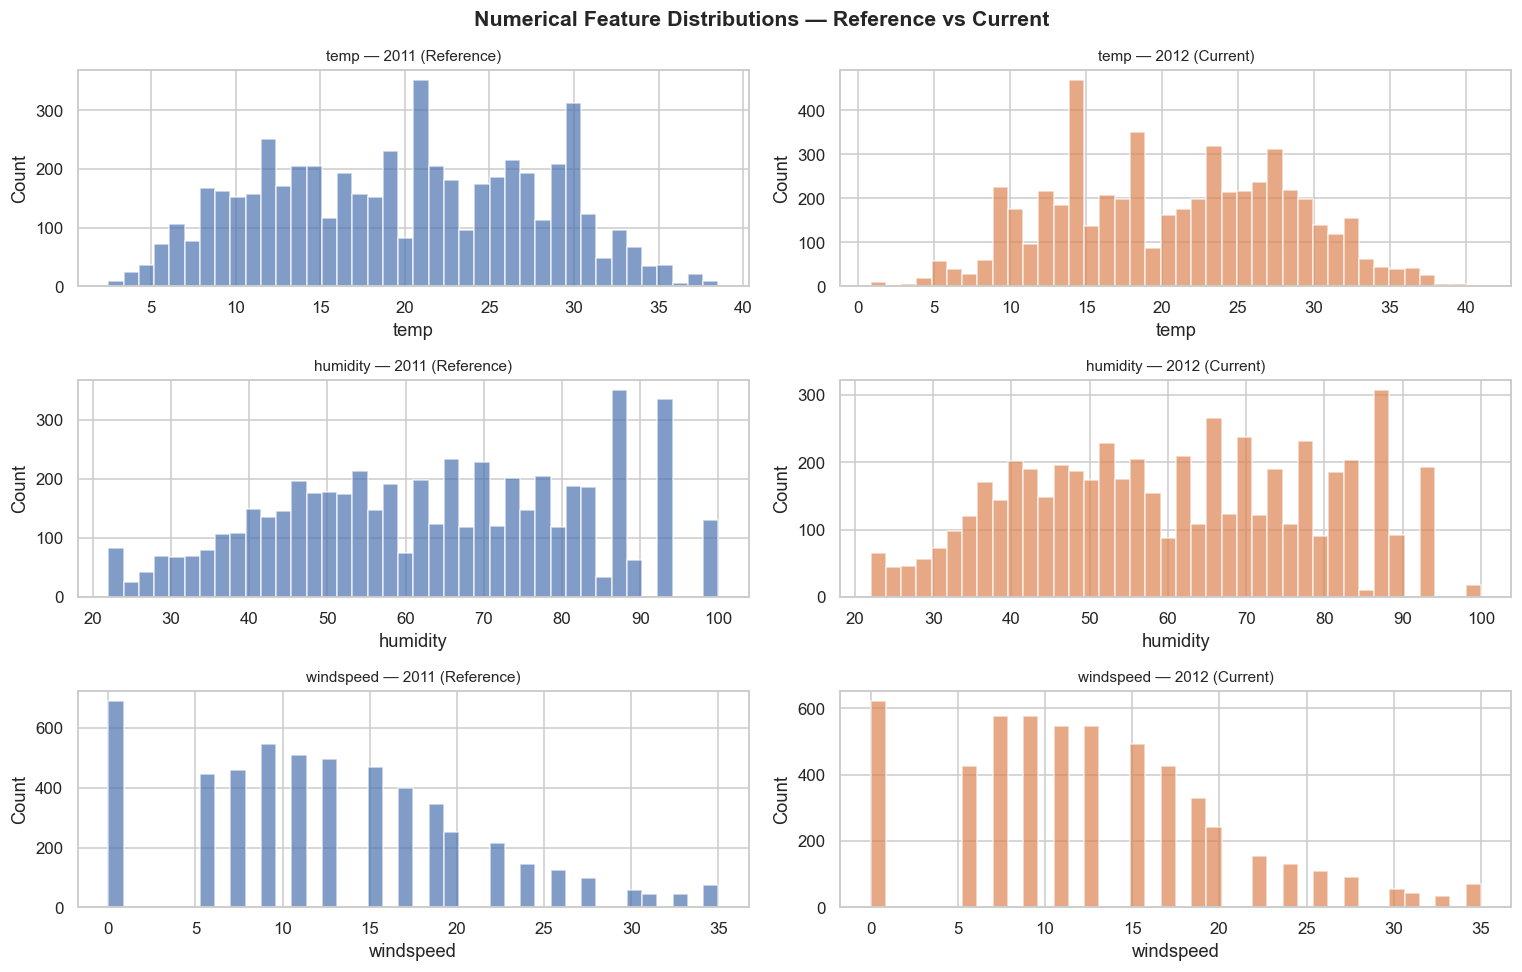

In [5]:
# atemp was dropped in preprocessing (r=0.99 with temp — multicollinear)
# workingday was dropped (redundant with dayofweek)
NUM_FEATURES = ["temp", "humidity", "windspeed"]
CAT_FEATURES = ["season", "holiday", "weather"]

fig, axes = plt.subplots(len(NUM_FEATURES), 2, figsize=(14, 3 * len(NUM_FEATURES)))
fig.suptitle("Numerical Feature Distributions — Reference vs Current", fontsize=14, fontweight="bold")

for ax_row, feat in zip(axes, NUM_FEATURES):
    for ax, (subset, label, color) in zip(ax_row, [
        (ref_df,  "2011 (Reference)", "#4C72B0"),
        (curr_df, "2012 (Current)",   "#DD8452"),
    ]):
        ax.hist(subset[feat].dropna(), bins=40, color=color, alpha=0.7, edgecolor="white")
        ax.set_title(f"{feat} — {label}", fontsize=10)
        ax.set_xlabel(feat)
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

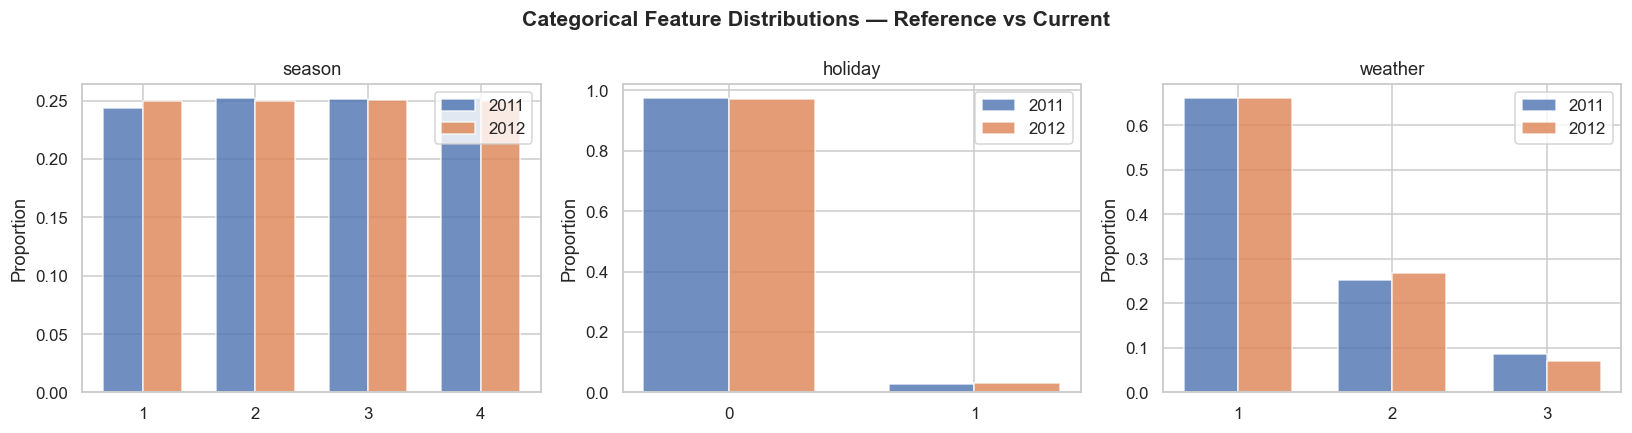

In [6]:
# Categorical features — bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Categorical Feature Distributions — Reference vs Current", fontsize=14, fontweight="bold")

for ax, feat in zip(axes, CAT_FEATURES):
    ref_counts  = ref_df[feat].value_counts(normalize=True).sort_index()
    curr_counts = curr_df[feat].value_counts(normalize=True).sort_index()
    idx = sorted(set(ref_counts.index) | set(curr_counts.index))
    x   = np.arange(len(idx))
    w   = 0.35
    ax.bar(x - w/2, [ref_counts.get(i, 0)  for i in idx], w, label="2011", color="#4C72B0", alpha=0.8)
    ax.bar(x + w/2, [curr_counts.get(i, 0) for i in idx], w, label="2012", color="#DD8452", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(idx)
    ax.set_title(feat); ax.set_ylabel("Proportion")
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Statistical Drift Tests

### Kolmogorov-Smirnov Test (numerical features)
The KS test checks whether two samples come from the same distribution.  
`p < 0.05` → statistically significant drift detected.

### Chi-Squared Test (categorical features)
Tests whether the observed category frequencies differ from the expected (reference) frequencies.

In [8]:
drift_results = []

# KS test — numerical
for feat in NUM_FEATURES:
    ks_stat, p_val = stats.ks_2samp(ref_df[feat].dropna(), curr_df[feat].dropna())
    drift_results.append({
        "feature": feat, "test": "KS",
        "statistic": round(ks_stat, 4), "p_value": round(p_val, 4),
        "drift_detected": p_val < 0.05
    })

# Chi-squared test — categorical
for feat in CAT_FEATURES:
    all_cats = sorted(set(ref_df[feat].unique()) | set(curr_df[feat].unique()))
    ref_counts  = ref_df[feat].value_counts().reindex(all_cats, fill_value=0)
    curr_counts = curr_df[feat].value_counts().reindex(all_cats, fill_value=0)
    chi2, p_val = stats.chisquare(curr_counts, f_exp=ref_counts * (len(curr_df) / len(ref_df)))
    drift_results.append({
        "feature": feat, "test": "Chi2",
        "statistic": round(chi2, 4), "p_value": round(p_val, 4),
        "drift_detected": p_val < 0.05
    })

drift_df = pd.DataFrame(drift_results)
print(drift_df.to_string(index=False))

  feature test  statistic  p_value  drift_detected
     temp   KS     0.0687   0.0000            True
 humidity   KS     0.0687   0.0000            True
windspeed   KS     0.0289   0.0207            True
   season Chi2     0.8845   0.8292           False
  holiday Chi2     3.3904   0.0656           False
  weather Chi2    22.9384   0.0000            True


## 4. Population Stability Index (PSI)

PSI measures how much a distribution has shifted:

| PSI value | Interpretation |
|-----------|---------------|
| < 0.10 | No significant drift |
| 0.10 – 0.25 | Moderate drift — investigate |
| > 0.25 | Major drift — retrain model |

In [9]:
def psi(expected, actual, bins=10):
    """Population Stability Index for a numerical feature."""
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints[0]  = -np.inf
    breakpoints[-1] = np.inf
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    # Avoid log(0)
    expected_pct = np.where(expected_pct == 0, 1e-6, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 1e-6, actual_pct)
    return np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))

psi_results = []
for feat in NUM_FEATURES:
    score = psi(ref_df[feat].dropna().values, curr_df[feat].dropna().values)
    psi_results.append({"feature": feat, "psi": round(score, 4),
                         "severity": "Major" if score > 0.25 else ("Moderate" if score > 0.10 else "Stable")})

psi_df = pd.DataFrame(psi_results)
print(psi_df.to_string(index=False))

  feature    psi severity
     temp 0.0514   Stable
 humidity 0.0372   Stable
windspeed 0.0081   Stable


## 5. Target Drift Analysis

Compare the distribution of the target variable `count` between 2011 and 2012.

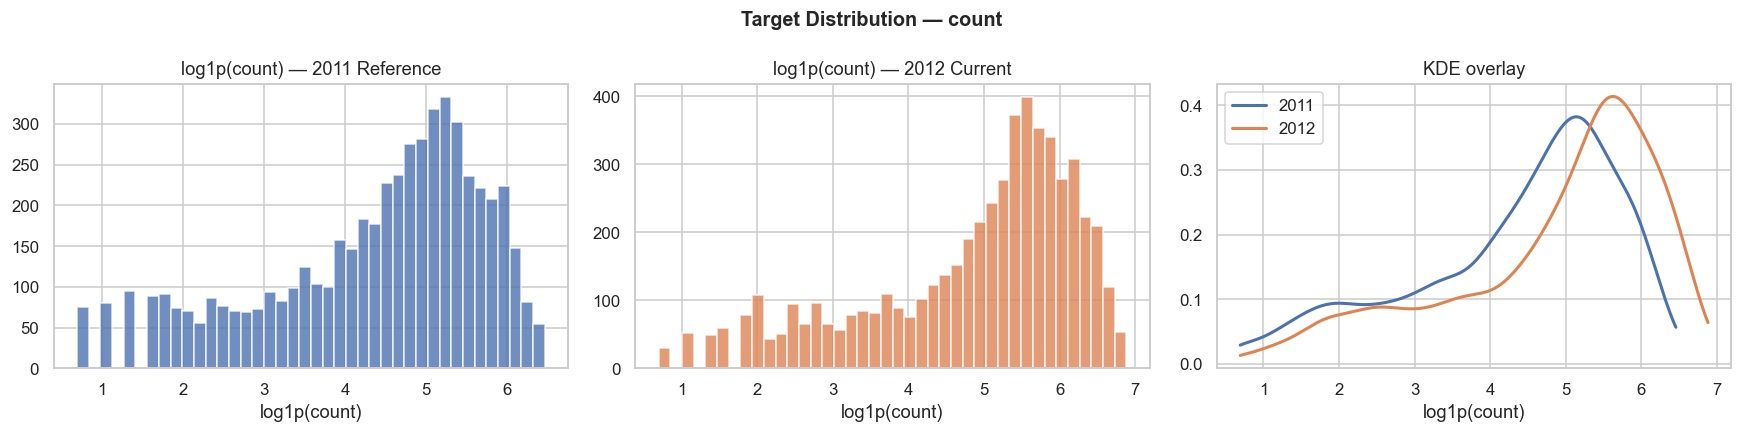

Target KS stat: 0.2307, p-value: 0.0000
Target drift: YES


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Target Distribution — count", fontsize=13, fontweight="bold")

# Histograms
for ax, (subset, label, color) in zip(axes[:2], [
    (ref_df,  "2011 Reference", "#4C72B0"),
    (curr_df, "2012 Current",   "#DD8452"),
]):
    ax.hist(np.log1p(subset["count"]), bins=40, color=color, alpha=0.8, edgecolor="white")
    ax.set(title=f"log1p(count) — {label}", xlabel="log1p(count)")

# KDE overlay
from scipy.stats import gaussian_kde
for subset, label, color in [
    (ref_df,  "2011", "#4C72B0"),
    (curr_df, "2012", "#DD8452"),
]:
    vals = np.log1p(subset["count"])
    kde  = gaussian_kde(vals)
    x    = np.linspace(vals.min(), vals.max(), 200)
    axes[2].plot(x, kde(x), color=color, label=label, linewidth=2)
axes[2].set(title="KDE overlay", xlabel="log1p(count)")
axes[2].legend()

plt.tight_layout()
plt.show()

# KS test on target
ks_stat, p_val = stats.ks_2samp(ref_df["count"], curr_df["count"])
print(f"Target KS stat: {ks_stat:.4f}, p-value: {p_val:.4f}")
print("Target drift:", "YES" if p_val < 0.05 else "NO")

## 6. Drift Summary Dashboard

In [11]:
# Combine all test results into a single dashboard table
all_tests = drift_df.copy()

# Merge PSI scores
all_tests = all_tests.merge(psi_df[["feature", "psi", "severity"]], on="feature", how="left")

# Colour coding helper
def highlight_drift(val):
    if val is True or val == "Major":
        return "background-color: #ffcccc"
    if val == "Moderate":
        return "background-color: #fff3cc"
    if val is False or val == "Stable":
        return "background-color: #ccffcc"
    return ""

print("=== Drift Summary ===")
styled = all_tests.style.applymap(highlight_drift, subset=["drift_detected", "severity"])
styled

=== Drift Summary ===


,feature,test,statistic,p_value,drift_detected,psi,severity
0,temp,KS,0.068700,0.000000,True,0.051400,Stable
1,humidity,KS,0.068700,0.000000,True,0.037200,Stable
2,windspeed,KS,0.028900,0.020700,True,0.008100,Stable
3,season,Chi2,0.884500,0.829200,False,nan,nan
4,holiday,Chi2,3.390400,0.065600,False,nan,nan
5,weather,Chi2,22.938400,0.000000,True,nan,nan


## 7. Drift Alerts & Retraining Recommendation

In [12]:
DRIFT_THRESHOLD_KS_P  = 0.05
DRIFT_THRESHOLD_PSI   = 0.10

print("=" * 55)
print("  DRIFT ALERT REPORT — 2011 (ref) vs 2012 (current)")
print("=" * 55)

retrain_recommended = False

for _, row in all_tests.iterrows():
    feat = row["feature"]
    if row["drift_detected"]:
        print(f"  [ALERT] {feat:20s}  {row['test']} p={row['p_value']:.4f}  ← DRIFT")
        retrain_recommended = True
    else:
        print(f"  [OK]    {feat:20s}  {row['test']} p={row['p_value']:.4f}")

print()
print(f"  PSI alerts (>{DRIFT_THRESHOLD_PSI}):")
for _, row in psi_df.iterrows():
    flag = "ALERT" if row["psi"] > DRIFT_THRESHOLD_PSI else "OK"
    print(f"  [{flag}]  {row['feature']:20s}  PSI={row['psi']:.4f}  ({row['severity']})")
    if row["psi"] > DRIFT_THRESHOLD_PSI:
        retrain_recommended = True

print()
print("=" * 55)
if retrain_recommended:
    print("  RECOMMENDATION: Drift detected — trigger CT pipeline")
    print("  (push to data/bronze/ or run ct.yml workflow)")
else:
    print("  RECOMMENDATION: No significant drift — monitor only")
print("=" * 55)

  DRIFT ALERT REPORT — 2011 (ref) vs 2012 (current)
  [ALERT] temp                  KS p=0.0000  ← DRIFT
  [ALERT] humidity              KS p=0.0000  ← DRIFT
  [ALERT] windspeed             KS p=0.0207  ← DRIFT
  [OK]    season                Chi2 p=0.8292
  [OK]    holiday               Chi2 p=0.0656
  [ALERT] weather               Chi2 p=0.0000  ← DRIFT

  PSI alerts (>0.1):
  [OK]  temp                  PSI=0.0514  (Stable)
  [OK]  humidity              PSI=0.0372  (Stable)
  [OK]  windspeed             PSI=0.0081  (Stable)

  RECOMMENDATION: Drift detected — trigger CT pipeline
  (push to data/bronze/ or run ct.yml workflow)


## 8. Time-Series Drift Visualisation

Plot rolling monthly averages for key features to see how they evolve over time.

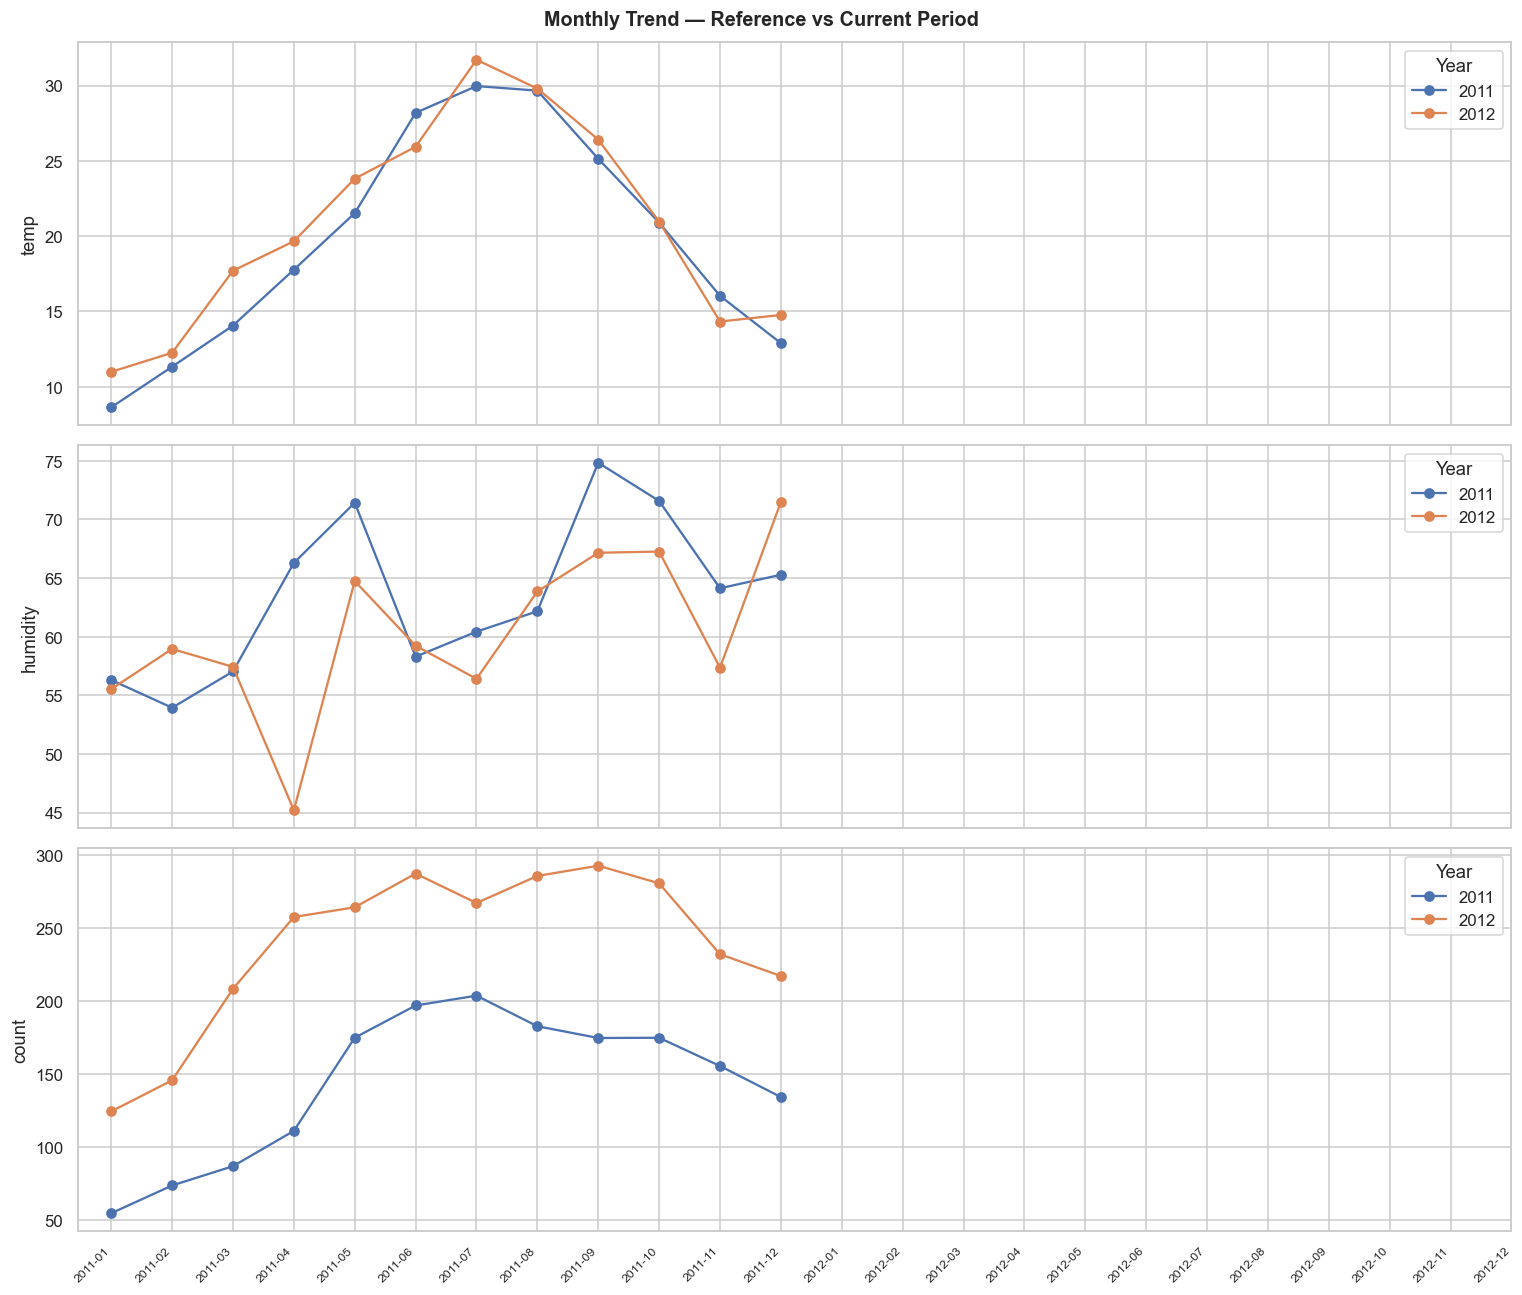

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Monthly Trend — Reference vs Current Period", fontsize=13, fontweight="bold")

full_df = pd.concat([ref_df.assign(period="2011"), curr_df.assign(period="2012")])
full_df["month_year"] = full_df["datetime"].dt.to_period("M").astype(str)

for ax, feat, color_map in zip(axes,
    ["temp", "humidity", "count"],
    [{"2011": "#4C72B0", "2012": "#DD8452"}] * 3
):
    for period, grp in full_df.groupby("period"):
        monthly = grp.groupby("month_year")[feat].mean()
        ax.plot(range(len(monthly)), monthly.values,
                marker="o", label=period, color=color_map[period], linewidth=1.5)
    ax.set_ylabel(feat)
    ax.legend(title="Year")

# Shared x-axis labels
periods = sorted(full_df["month_year"].unique())
axes[-1].set_xticks(range(len(periods)))
axes[-1].set_xticklabels(periods, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Summary

| Area | Finding |
|------|---------|
| Numerical features | Temperature, humidity drift between years (expected — seasonal growth) |
| Categorical features | Season/weather distributions relatively stable |
| Target | Significant upward shift in 2012 (more users registered year 2) |
| PSI | Features with PSI > 0.10 warrant attention |
| **Recommendation** | Trigger CT pipeline; retrain with combined 2011+2012 data |

> **MLOps action:** Push updated data to `data/bronze/` to trigger the `ct.yml` Continuous Training workflow.